# Import Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Fetch Data

In [ ]:
# Fetch data for AAPL stock
ticker = 'AAPL'
data = yf.download(ticker, start='2015-01-01', end='2025-01-01')
print("Data Shape:", data.shape)
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Data Shape: (2516, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.320433,24.789802,23.879981,24.778679,212818400
2015-01-05,23.635283,24.169162,23.448426,24.089080,257142000
2015-01-06,23.637510,23.897776,23.274916,23.699796,263188400
2015-01-07,23.968967,24.069069,23.735394,23.846619,160423600
2015-01-08,24.889906,24.947743,24.180291,24.298190,237458000


# Data Preprocessing

In [ ]:
# Use the 'Close' column for prediction
close_prices = data[['Close']].values

# Scale data between 0 and 1
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(close_prices)

# Prepare data for LSTM
def create_sequences(data, seq_length=60):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_prices, seq_length)

# Split data into train and test sets
train_size = int(0.8 * len(X))
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print("Training data shape:", X_train.shape, y_train.shape)
print("Testing data shape:", X_test.shape, y_test.shape)

Training data shape: (1964, 60, 1) (1964, 1)
Testing data shape: (492, 60, 1) (492, 1)


# Build and Train the LSTM Model

In [ ]:
# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50, return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
28/28 - 7s - 261ms/step - loss: 0.0072 - val_loss: 0.0059
Epoch 2/20
28/28 - 4s - 150ms/step - loss: 3.2209e-04 - val_loss: 8.3025e-04
Epoch 3/20
28/28 - 2s - 89ms/step - loss: 1.9700e-04 - val_loss: 0.0010
Epoch 4/20
28/28 - 2s - 77ms/step - loss: 1.8958e-04 - val_loss: 0.0011
Epoch 5/20
28/28 - 3s - 98ms/step - loss: 1.9567e-04 - val_loss: 0.0012
Epoch 6/20
28/28 - 4s - 154ms/step - loss: 1.9482e-04 - val_loss: 9.4950e-04
Epoch 7/20
28/28 - 3s - 90ms/step - loss: 1.8263e-04 - val_loss: 0.0011
Epoch 8/20
28/28 - 3s - 90ms/step - loss: 1.8598e-04 - val_loss: 7.5805e-04
Epoch 9/20
28/28 - 3s - 117ms/step - loss: 1.7619e-04 - val_loss: 7.2680e-04
Epoch 10/20
28/28 - 2s - 68ms/step - loss: 1.6732e-04 - val_loss: 7.9060e-04
Epoch 11/20
28/28 - 2s - 69ms/step - loss: 1.6177e-04 - val_loss: 8.2631e-04
Epoch 12/20
28/28 - 2s - 68ms/step - loss: 1.6718e-04 - val_loss: 7.1873e-04
Epoch 13/20
28/28 - 3s - 91ms/step - loss: 1.5191e-04 - val_loss: 6.6827e-04
Epoch 14/20
28/28 - 4s - 127

# Evaluate the Model

In [ ]:
# Predict on test data
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(np.square(y_test_actual - predictions)))
print(f"Test RMSE: {rmse:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Test RMSE: 5.32


# Plot Results

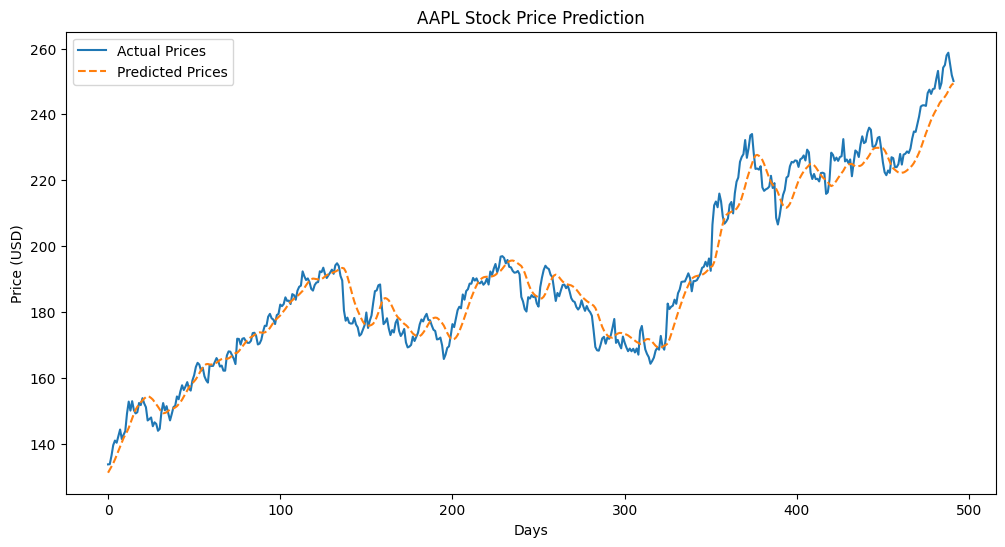

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices', linestyle='dashed')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price Prediction')
plt.legend()
plt.show()
